# Loading required libraries

In [82]:
library(ggplot2)
library(patchwork)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)

Warning message:
“package ‘survival’ was built under R version 4.4.3”

Attaching package: ‘survival’


The following object is masked _by_ ‘.GlobalEnv’:

    myeloid


The following object is masked from ‘package:survminer’:

    myeloma




## Figures and Files Setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_3"

## Color palettes

In [3]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

## Loading required data

In [4]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor_...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [36]:
celltype_percentage_exp <- read.csv(paste0(data_dir, "/celltype_percentage_exp.csv")) %>%
   mutate(patient_exp = factor(patient_exp, levels = patient_exp_order),
          patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
   arrange(patient_exp, patient_ID, cell_category)

celltype_percentage_patient <- read.csv(paste0(data_dir, "/celltype_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category)

cellgroup_percentage_patient <- read.csv(paste0(data_dir, "/cellgroup_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order),
    cell_category_simplified = factor(cell_category_simplified, levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")))

In [62]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

# A

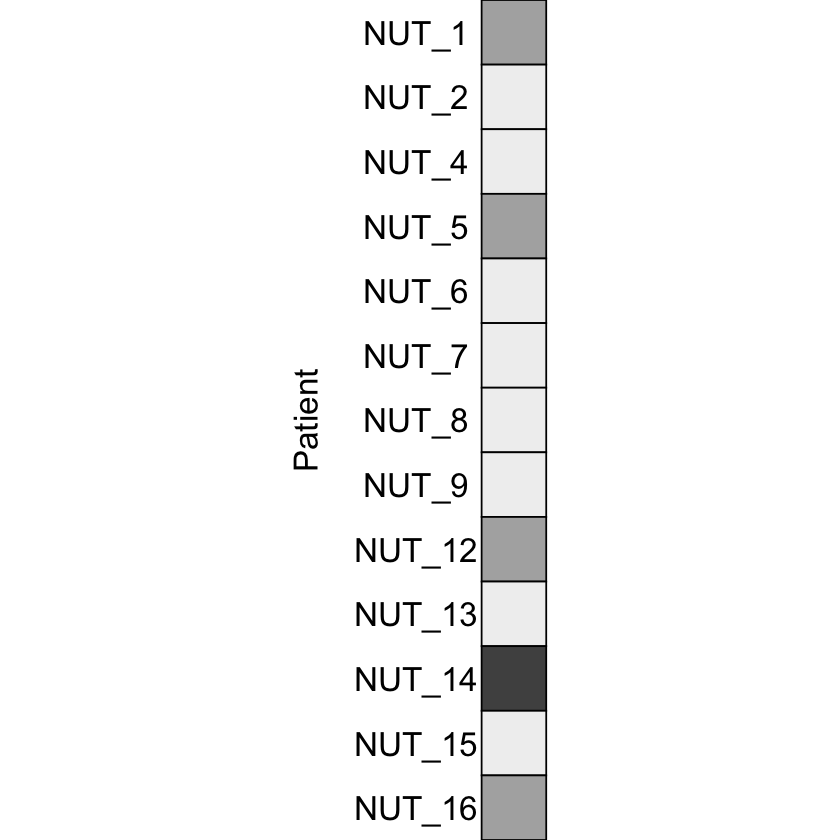

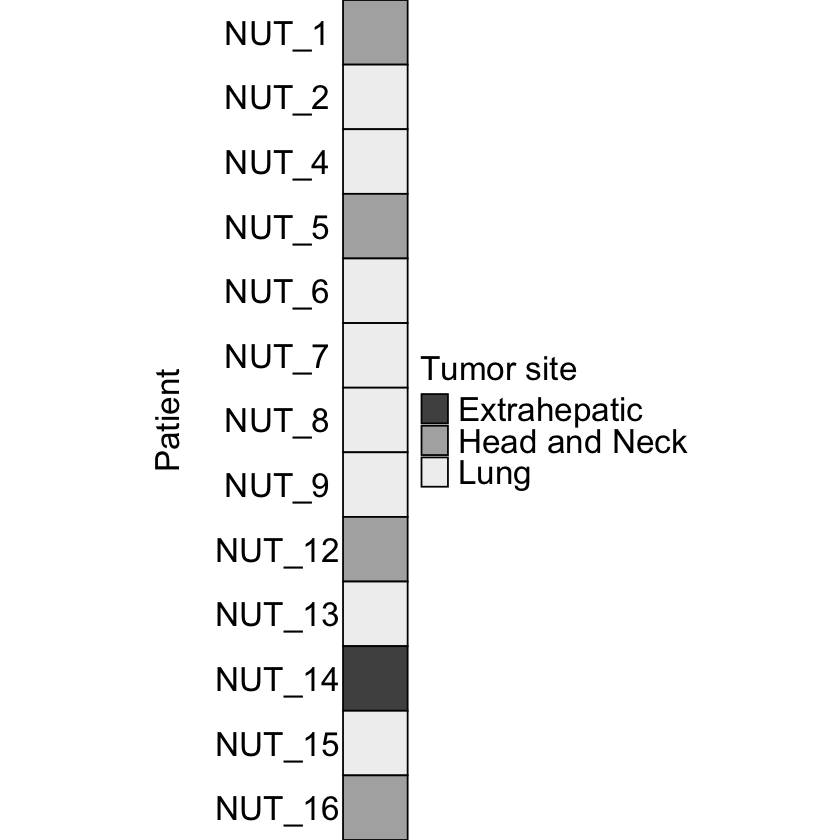

In [38]:
tumor_site_df <- celltype_metadata %>% 
    select(patient_ID, tumor_site) %>%
    distinct() 

tumor_site_plot <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
         legend.position = "none",
)
  tumor_site_plot

tumor_site_legend <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors, name = "Tumor site") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
      legend.position = "right",
      legend.text = element_text(size = 20),
      legend.title = element_text(size = 20),
      legend.spacing.y = unit(3, "cm"))
tumor_site_legend
#extract the legend
tumor_site_legend_only <- get_legend(tumor_site_legend)
#save the legend
ggsave(
  filename = paste0(results_dir, "/tumor_site_legend.pdf"),
  plot = tumor_site_legend_only,
  width = 4,
  height = 4,
  dpi = 300
)

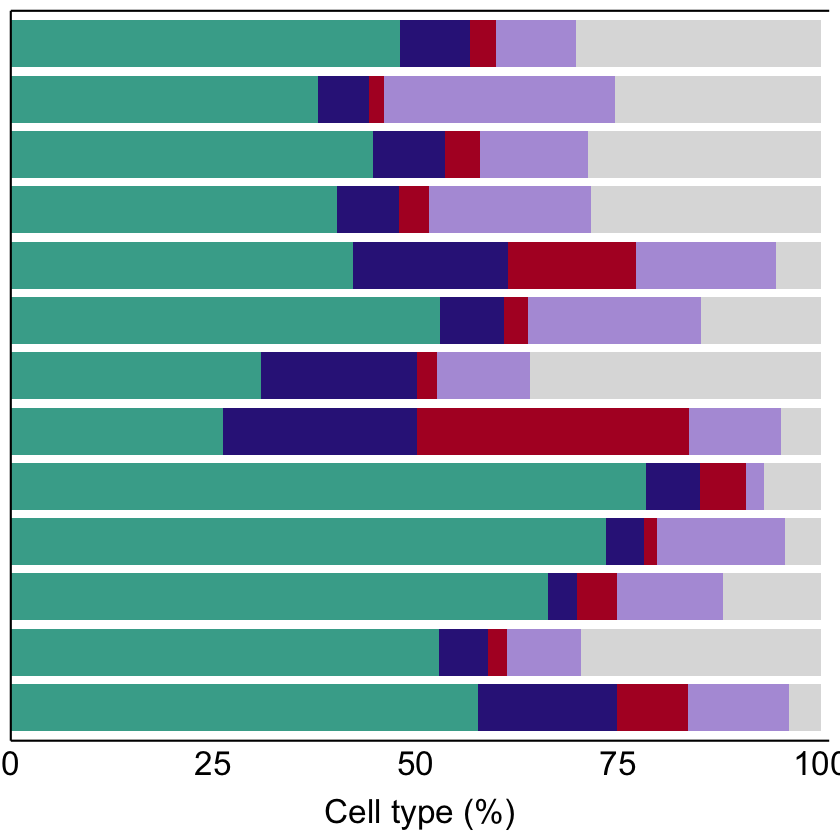

In [39]:
p_main = ggplot(
  cellgroup_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category_simplified)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = main_group_colors) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cell type (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )
p_main

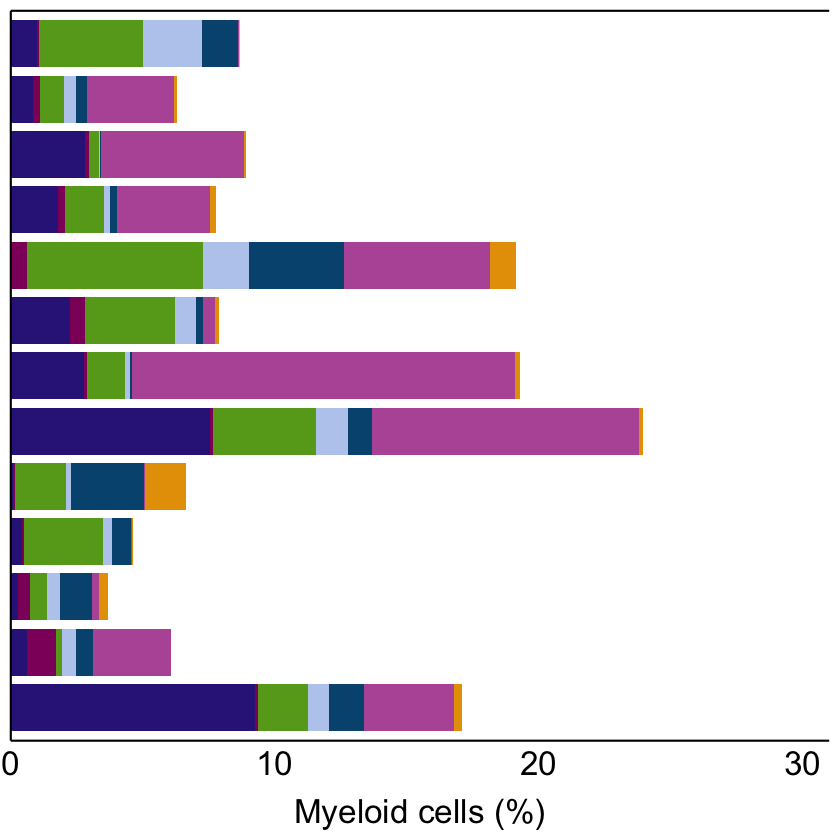

In [40]:
celltype_percentage_patient_myeloid <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Myeloid")

p_myeloid = ggplot(
  celltype_percentage_patient_myeloid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = myeloid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Myeloid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x  = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",

  )
p_myeloid

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


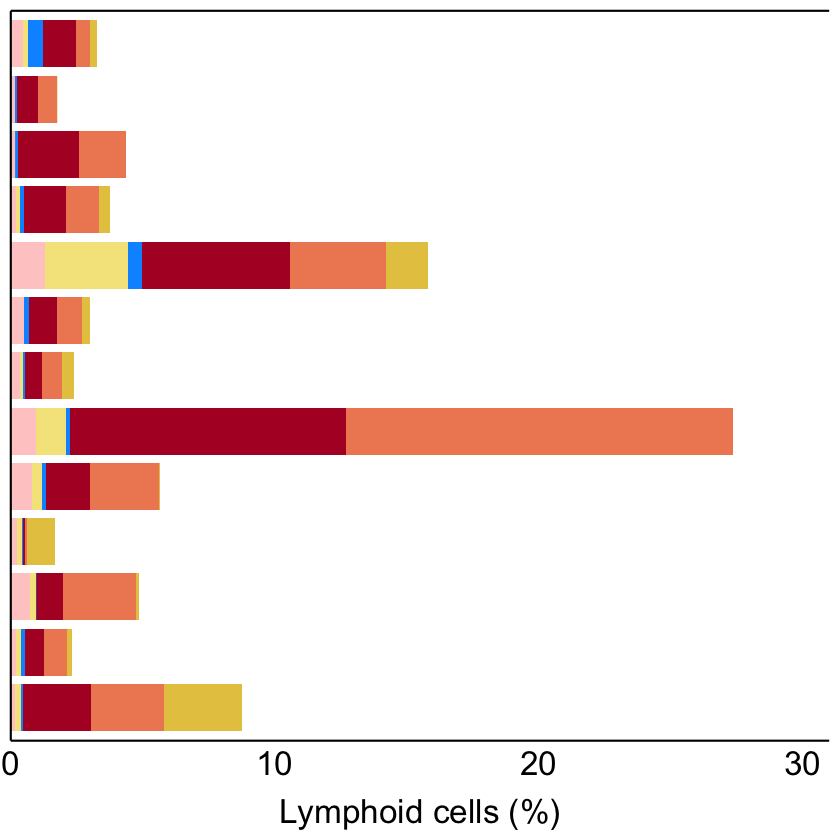

In [41]:
celltype_percentage_patient_lymphoid <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Lymphoid")


p_lymphoid = ggplot(
  celltype_percentage_patient_lymphoid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = lymphoid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Lymphoid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    axis.line = element_line(colour = "black", linewidth = 0.6),
    panel.grid = element_blank(),
    legend.position = "none",
  )
p_lymphoid

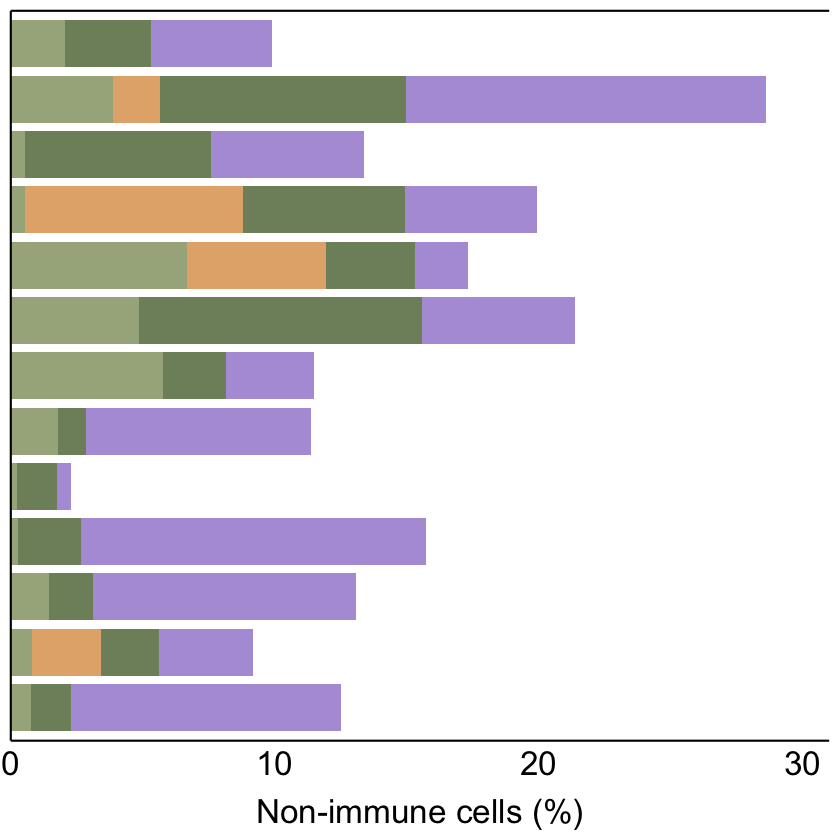

In [42]:
celltype_percentage_patient_nonimmune <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Non-immune")


p_nonimmune = ggplot(
  celltype_percentage_patient_nonimmune,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = non_immune_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Non-immune cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",

  )
p_nonimmune

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


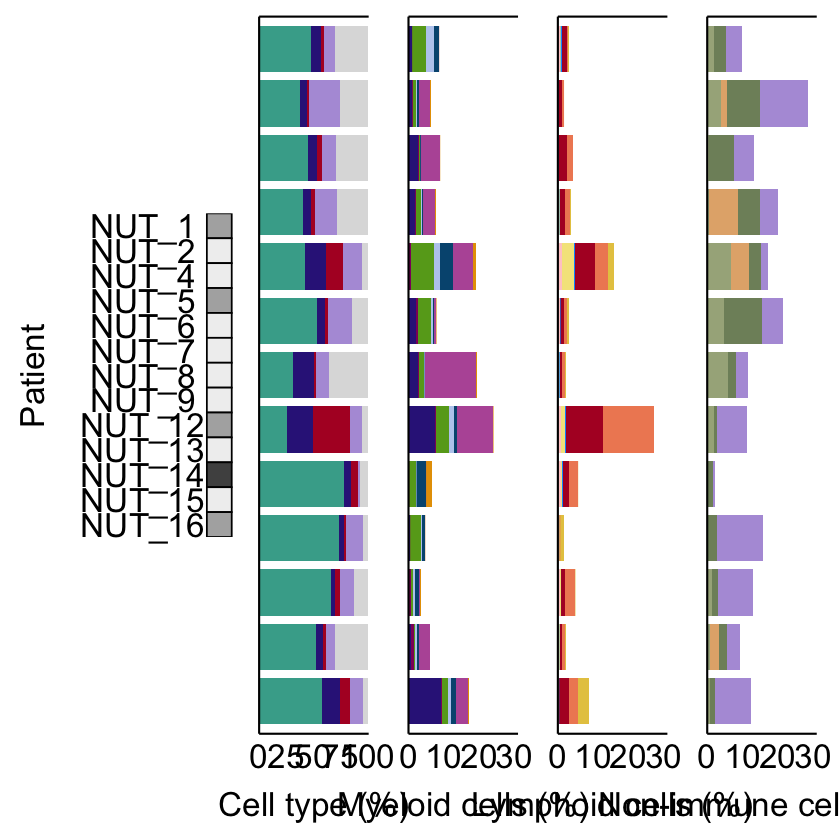

In [43]:
final_plot <- wrap_plots(
  tumor_site_plot, plot_spacer(), p_main, plot_spacer(), p_myeloid, plot_spacer(), p_lymphoid, plot_spacer(), p_nonimmune,
  ncol = 9,
  widths = c(1,-0.5,4,-0.001,4,-0.001,4,-0.001,4)
) & theme(plot.margin = margin(t=5, r=7, b=5, l=5))
final_plot
ggsave(
  filename = paste0(results_dir, "/cellular_proportions_barplot.pdf"),
  plot = final_plot,
  width = 20,
  height = 6,
  dpi = 300
)


# B

Warning message in geom_beeswarm(width = 0.15, size = 2, alpha = 0.8, color = "black"):
“Ignoring unknown parameters: `width`”


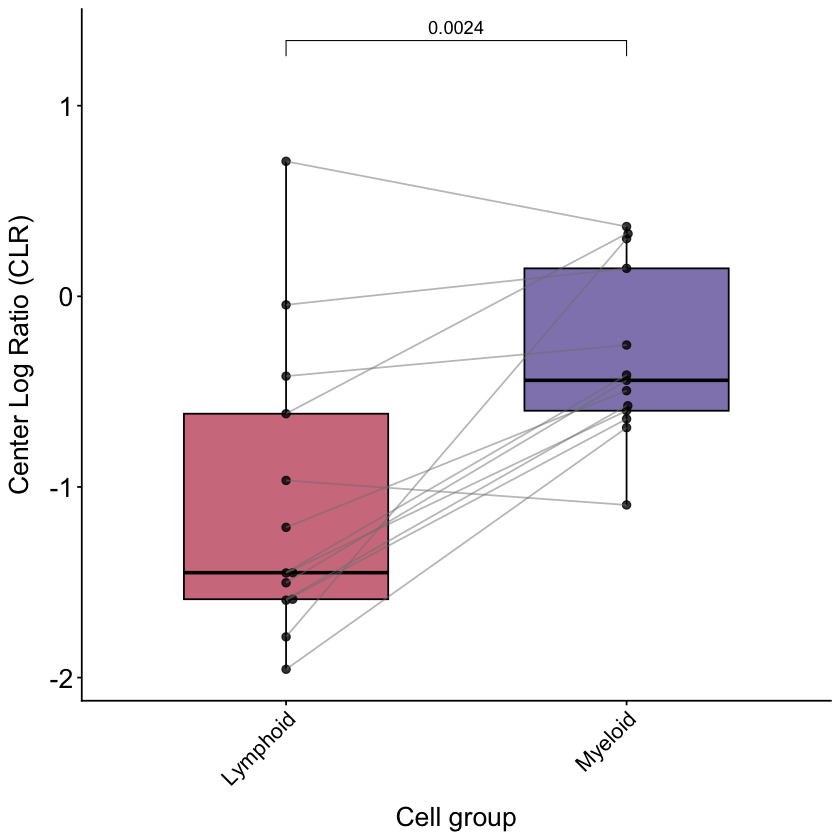

In [52]:
cellgroup_percentage_patient_mvsl <- cellgroup_percentage_patient %>%
filter(cell_category_simplified %in% c("Myeloid", "Lymphoid"))

pd <- position_dodge(0.8)
# Nice boxplot with Wilcoxon test and medians
p <- ggplot(cellgroup_percentage_patient_mvsl, 
            aes(x = cell_category_simplified, y = clr, fill = cell_category_simplified)) +
   geom_boxplot(
    position = pd,
    width = 0.6,
    alpha = 0.6,
    color = "black",
    outlier.shape = NA
  ) +
  geom_beeswarm(
    width = 0.15,
    size = 2,
    alpha = 0.8,
    color = "black"
  ) +
  # Add Wilcoxon p-values
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format",
    paired = TRUE,
    label.y = max(cellgroup_percentage_patient_mvsl$clr, na.rm = TRUE) + 0.5,
    label.x = 1.5,
    comparisons = list(c("Lymphoid", "Myeloid")),
    aes(group = cell_category_simplified, size = 13)
  ) +
    geom_line(
    aes(group = patient_ID),
    color = "grey50",
    alpha = 0.5,
    linewidth = 0.5
  ) +
  scale_fill_manual(values = main_group_colors) +
  labs(
    x = "Cell group",
    y = "Center Log Ratio (CLR)",
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  )
p
#save as svg
ggsave(filename = paste0(results_dir,"/myeloid_lymphoid_boxplot.pdf"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")


# C

In [53]:
#summarise the cell categories by their mean, sd, se.. we want to make error bars plot
celltype_percentage_patient_myeloid_summary <- celltype_percentage_patient_myeloid %>%
group_by(cell_category) %>%
summarise(
  mean_percentage = mean(percentage, na.rm = TRUE),
  sd_percentage = sd(percentage, na.rm = TRUE),
  se_percentage = sd_percentage / sqrt(n()),
  .groups = "drop"
)
celltype_percentage_patient_myeloid_summary

cell_category,mean_percentage,sd_percentage,se_percentage
<chr>,<dbl>,<dbl>,<dbl>
DCs,0.3399458,0.4635188,0.13380634
Granulocytes,3.8143506,4.3561515,1.20817905
M1 macrophages,1.0458556,1.0633736,0.29492676
M1/M2 macrophages,0.7099995,0.6589952,0.18277239
M2 macrophages,2.2971838,1.8363235,0.50930450
MDSCs,2.4764938,2.9431115,0.84960311
Mast cells,0.2979044,0.3098402,0.08593421


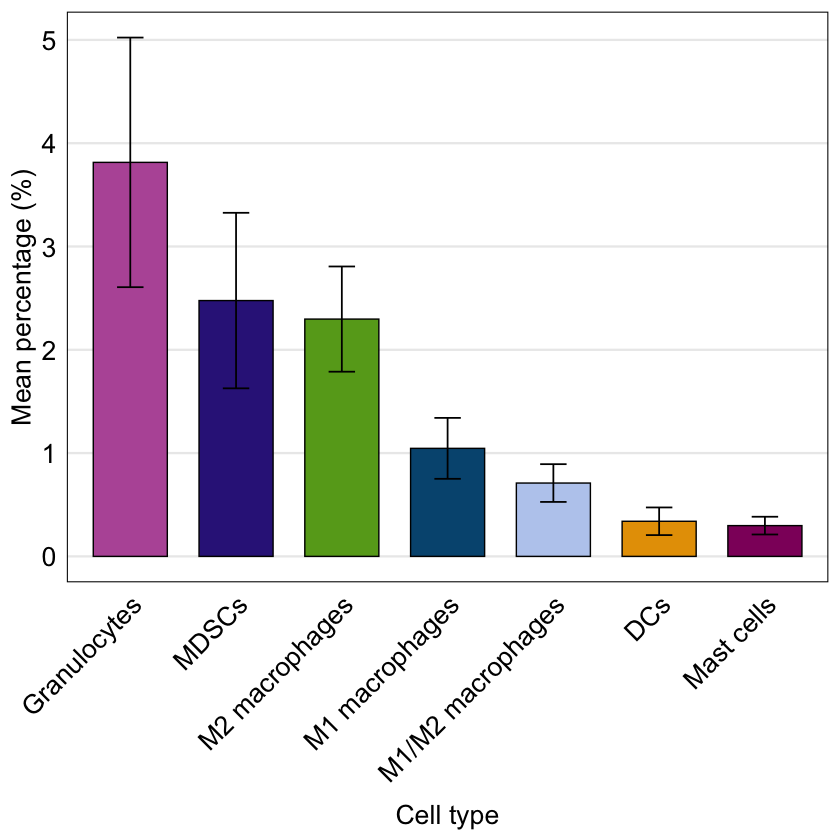

In [55]:
myeloid_errorbar_plot = ggplot(
  celltype_percentage_patient_myeloid_summary,
  aes(x = reorder(cell_category, -mean_percentage), 
      y = mean_percentage, 
      fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.7, color = "black", linewidth = 0.4) +
  geom_errorbar(
    aes(ymin = mean_percentage - se_percentage, 
        ymax = mean_percentage + se_percentage),
    width = 0.25,
    linewidth = 0.5,
    color = "black"
  ) +
  labs(
    x = "Cell type",
    y = "Mean percentage (%)",
  ) +
  scale_fill_manual(values = full_palette) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(color = "black", size = 16, angle = 45, hjust = 1),
    axis.text.y = element_text(color = "black", size = 16),
    axis.title.x = element_text(color = "black", size = 16, margin = margin(t = 10)),
    axis.title.y = element_text(color = "black", size = 16),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
    legend.position = "none"
  )

myeloid_errorbar_plot
#save the plot
ggsave(
  filename = paste0(results_dir, "/myeloid_errorbar_plot.pdf"),
  plot = myeloid_errorbar_plot,
  width = 5,
  height = 5,
  dpi = 300
)

# D

In [63]:
celltype_percentage_patient_survival <- celltype_percentage_patient %>%
  left_join(
    survival_df,
    by = "patient_ID"
  ) %>%
  arrange(tumor_site, survival_time_months)

celltype_percentage_patient_survival_myeloid <- celltype_percentage_patient_survival %>%
filter(cell_category_simplified == "Myeloid")

celltype_percentage_patient_survival_myeloid_ht <- celltype_percentage_patient_survival_myeloid %>%
    select(patient_ID, cell_category, clr) %>%
    pivot_wider(names_from = patient_ID, values_from = clr) %>%
    column_to_rownames(var = "cell_category") %>%
    as.matrix()
col_split <- survival_df %>%
  arrange(tumor_site, survival_time_months) %>%
  pull(tumor_site) 
  #remove the factor
celltype_percentage_patient_survival_myeloid_ht

,NUT_9,NUT_2,NUT_4,NUT_8,NUT_15,NUT_13,NUT_6,NUT_7,NUT_5,NUT_16,NUT_12,NUT_1,NUT_14
DCs,-2.5732919,-2.39040616,-2.3365387,-1.7186793,NA,-2.55709437,-1.1408795,-2.0182651,-2.0411021,-1.2301154,0.9029646,-3.4733861,-1.1700732
Granulocytes,1.4945112,1.19588671,2.1370031,2.7143499,1.06970373,-2.84700362,0.5966880,-1.3322760,1.1589058,0.9154100,-2.8448574,-3.3618143,-1.2557938
M1 macrophages,-0.7883473,-0.88632876,-2.5596822,-2.4353570,-0.49549400,0.34523209,0.1693625,-1.7126195,-1.8566552,0.1011700,1.4688139,0.4686668,0.3538327
M1/M2 macrophages,-0.5091398,-0.78096824,-3.2528294,-1.6512380,-0.65466712,-0.25291183,-0.5655154,-0.6754385,-1.5229456,-0.3895413,-1.3895701,1.0057955,-0.5608118
M2 macrophages,0.6652293,-0.07293245,-0.5447792,0.4089985,-1.48610226,1.95225337,0.7831479,1.0479240,0.2374356,0.3478107,1.1173154,1.5040012,-0.3575842
MDSCs,1.3201017,-0.14969647,1.4760323,1.0640324,-0.87987197,0.02128253,NA,0.6499086,0.4372894,2.1879135,-1.8463285,0.1066485,-1.1539725
Mast cells,-3.5871129,-1.37880524,-1.3557094,-2.2217829,0.07100177,-2.11936000,-1.6035031,-0.9386838,-1.4274725,-2.6063084,-2.4881824,-2.8470046,-0.6249139


In [81]:
# Pink → Green (PiYG)
col_fun <- colorRamp2(
  c(-2, -1, 0, 1, 2),
  c("#F7F7F7", "#C7EAE5", "#80CDC1", "#35978F", "#01665E")
)

survival_vals <- survival_df %>%
  arrange(tumor_site, survival_time_months) %>%
  pull(survival_time_months) %>%
  pmin(20)  # cap at 20

annot = HeatmapAnnotation(survival = anno_barplot(survival_vals,
height        = unit(2, "cm"),
axis_param    = list(
      gp          = gpar(fontsize = 13),
      at          = c(0, 10, 20),
      labels      = c("0", "10", "≥20")
    ),
  annotation_name_gp   = gpar(fontsize = 13),
  annotation_name_side = "right"
))

ht <- Heatmap(
celltype_percentage_patient_survival_myeloid_ht,
name = "CLR",
col = col_fun,
na_col = "grey85",
column_title = "Patients",
row_title = "Cell types",
show_row_names = TRUE,
show_column_names = TRUE,
column_names_rot = 45,
cluster_rows = FALSE,
cluster_columns = FALSE,
column_names_gp = gpar(fontsize = 13),
row_names_gp = gpar(fontsize = 13),
column_title_gp = gpar(fontsize = 13),
row_title_gp = gpar(fontsize = 13),
row_gap           = unit(3, "mm"),
column_gap        = unit(3, "mm"),
row_names_side = "left",
column_split = col_split,
bottom_annotation = annot,
# rect_gp = gpar(col = "white", lwd = 0.5),
#heatmap legend
heatmap_legend_param = list(
    title            = "Center Log Ratio (CLR)",
    title_gp         = gpar(fontsize = 13),
    labels_gp        = gpar(fontsize = 13),
    at               = c(-2,0,2),
    legend_direction = "vertical"
  ),
)

pdf(
  file   = paste0(results_dir, "/clr_heatmap.pdf"),
  width  = 10,
  height = 5
)
draw(ht,
     heatmap_legend_side   = "right",
     annotation_legend_side = "right",
     padding = unit(c(5, 5, 5, 5), "mm"))
dev.off()

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥20' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


agg_record_771107910 
                   2

In [ ]:
celltype_percentage_patient_survival_myeloid

In [92]:
df <- celltype_percentage_patient_survival_myeloid %>%
filter(cell_category == "Granulocytes")

#calculate median percentage for the cell category

#create a new column that is "High" if the percentage is above the median and "Low" if it is below the median
df <- df %>%
mutate(clr_group = factor(ifelse(is.na(clr) | clr < 0, "Low", "High"), levels = c("Low", "High")))
#perform a survival analysis using the percentage group as the variable of interest
fit <- survfit(Surv(survival_time_months, event) ~ clr_group, data = df)
# Plot
surv_plot <- ggsurvplot(
fit,
data = df,
pval = TRUE,
conf.int = TRUE,
risk.table = TRUE,
risk.table.height = 0.25,
pval.coord = c(17, 0.7),
xlim = c(0, 20),
break.time.by = 5,
palette = c("#2E86AB", "#E74C3C"),
xlab = "Time (months)",
ylab = "Survival probability",
title = paste("Survival by", "Granulocytes", "proportions"),
legend.title = 'Granulocytes',
legend.labs = c(paste("Low", "Granulocytes", "CLR"), paste("High", "Granulocytes", "CLR")),
risk.table.y.text.col = TRUE,
risk.table.y.text = FALSE,
ggtheme = theme_classic(base_size = 13)
)

filename <- paste0(results_dir, "/Granulocytes_proportions_CLR_survival_plot.pdf")
ggsave(
filename = filename, 
plot = surv_plot$plot, 
width = 7, 
height = 6, 
dpi = 300)
filename <- paste0(results_dir, "/Granulocytes_proportions_CLR_survival_plot_table.pdf")
ggsave(
filename = filename, 
plot = surv_plot$table, 
width = 7, 
height = 2, 
dpi = 300)



Ignoring unknown labels:
• colour : "Granulocytes"
